<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records

df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [4]:
##Write your code here
industry_counts=df["Industry"].value_counts()

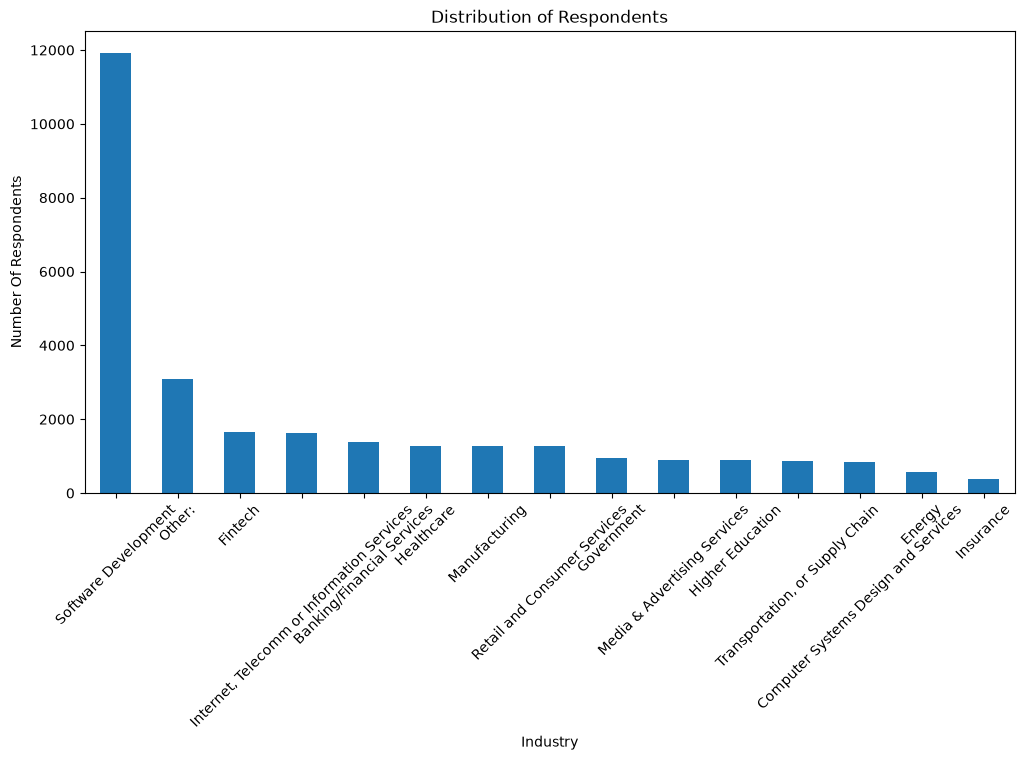

In [10]:
industry_counts.plot(kind="bar",figsize=(12,6))
plt.title("Distribution of Respondents")
plt.xlabel("Industry")
plt.ylabel("Number Of Respondents")
plt.xticks(rotation=45)

plt.show()




<h3>Step 3: Identify High Compensation Outliers</h3>



Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [12]:
##Write your code here
df["ConvertedCompYearly"].describe()



count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [15]:
threshold=df["ConvertedCompYearly"].mean()+3*df["ConvertedCompYearly"].std()
outliers=df[df["ConvertedCompYearly"]>threshold]
len(outliers)

89

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [17]:
##Write your code here
Q1=df["ConvertedCompYearly"].quantile(0.25)
Q3=df["ConvertedCompYearly"].quantile(0.75)
IQR=Q3-Q1

In [20]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df["ConvertedCompYearly"]<lower_bound)|(df["ConvertedCompYearly"]>upper_bound)
]
len(outliers)

978

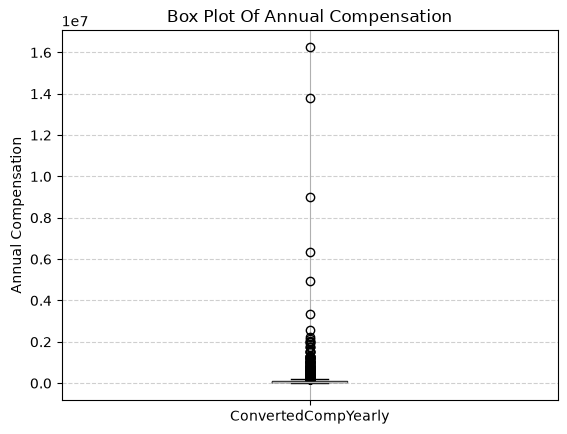

In [24]:
df.boxplot(column="ConvertedCompYearly")
plt.title("Box Plot Of Annual Compensation")
plt.ylabel("Annual Compensation")
plt.grid(axis="y",linestyle="--",alpha=0.6)

plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>



Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [26]:
##Write your code here
df_no_outliers=df[(df["ConvertedCompYearly"]>=lower_bound
                  )&(df["ConvertedCompYearly"]<=upper_bound)]

In [27]:
df_no_outliers.shape

(22457, 114)

In [28]:
df.shape

(65437, 114)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [29]:
##Write your code here
df["Age"].unique()


<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [30]:
age_map={'Under 18 years old':16,    '35-44 years old':21,    '45-54 years old':30,
    '18-24 years old':40,    '25-34 years old':50,    '55-64 years old':60,
  'Prefer not to say':None,  '65 years or older':70}

In [31]:
df["Age_Numeric"]=df["Age"].map(age_map)

In [35]:
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": "0",
    "More than 50 years": "50"
})

df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

In [36]:
corr=df[["Age_Numeric","ConvertedCompYearly","YearsCodePro"]].corr()




In [37]:
corr

,Age_Numeric,ConvertedCompYearly,YearsCodePro
Age_Numeric,1.000000,-0.045448,-0.158140
ConvertedCompYearly,-0.045448,1.000000,0.141071
YearsCodePro,-0.158140,0.141071,1.000000


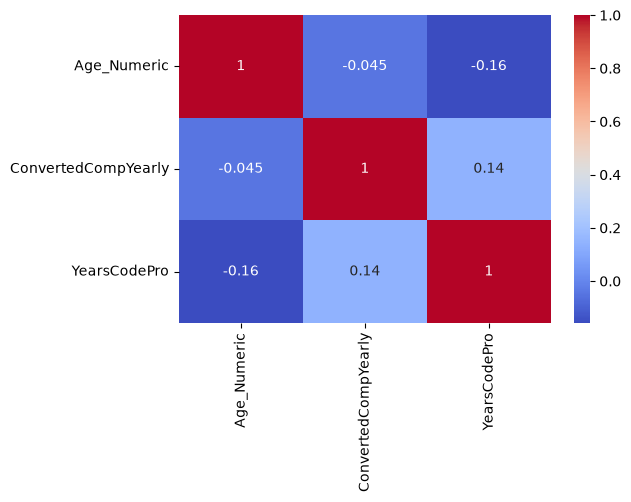

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
